In [ ]:
import re
import numpy as np
import pandas as pd
import datetime

In [ ]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/narendramodi_tweets.csv'
tweets = pd.read_csv(url)
tweets.shape

(3220, 14)

# Hashtag Trend Analysis

In [ ]:
def compute_hashtag_freq(docs):
  all_hashtags = []
  for tweet in docs:
    words_clean = re.findall('[a-zA-Z0-9#]+', tweet.lower())
    hashtags = [word for word in words_clean if word.startswith('#') and word != '#']
    all_hashtags.extend(hashtags)
  hashtags_freq = pd.Series(all_hashtags).value_counts()
  return hashtags_freq
result = compute_hashtag_freq(tweets['text'])

## Date operations

In [ ]:
today = "2021-09-20"
print(today[5:7])
print(today.split('-'))
print(today.split('-')[1])

09
['2021', '09', '20']
09


In [ ]:
import datetime
# https://docs.python.org/3/library/datetime.html
today = "2021-09-20"
today_datetime = datetime.datetime.strptime(today, '%Y-%m-%d')
type(today_datetime)

datetime.datetime

In [ ]:
today = '20/Oct/2020'
today_datetime = datetime.datetime.strptime(today, '%d/%b/%Y')
today_datetime

datetime.datetime(2020, 10, 20, 0, 0)

In [ ]:
year = datetime.datetime.strftime(today_datetime, '%Y')
month = datetime.datetime.strftime(today_datetime, '%m')
dow = datetime.datetime.strftime(today_datetime, '%A')
year_month = datetime.datetime.strftime(today_datetime, '%Y_%m')
year, month, dow, year_month

('2020', '10', 'Tuesday', '2020_10')

In [ ]:
tweets.dtypes

id                      float64
retweets_count          float64
favorite_count          float64
created_at               object
text                     object
lang                     object
retweeted                  bool
followers_count         float64
friends_count           float64
hashtags_count          float64
description              object
location                 object
background_image_url     object
source                   object
dtype: object

In [ ]:
tweets.head(2)

,id,retweets_count,favorite_count,created_at,text,lang,retweeted,followers_count,friends_count,hashtags_count,description,location,background_image_url,source
0,8.263846e+17,1406.0,4903.0,2017-01-31 11:00:07,The President's address wonderfully encapsulat...,en,False,26809964.0,1641.0,1.0,Prime Minister of India,India,http://pbs.twimg.com/profile_background_images...,Twitter Web Client
1,8.263843e+17,907.0,2877.0,2017-01-31 10:59:12,Rashtrapati Ji's address to both Houses of Par...,en,False,26809964.0,1641.0,0.0,Prime Minister of India,India,http://pbs.twimg.com/profile_background_images...,Twitter Web Client


In [ ]:
tweets['date'] = pd.to_datetime(tweets['created_at'],
                                format="%Y-%m-%d %H:%M:%S")
tweets['year'] = tweets['date'].dt.year
tweets['month'] = tweets['date'].dt.month
tweets['dow'] = tweets['date'].dt.strftime('%a')
tweets['year_month'] = tweets['date'].dt.strftime('%Y_%m')


## Apply method
Is used to apply a function in all rows of a data frame

### Exercise: For a given hashtag, identify monthwise frequency

In [ ]:
hashtag = '#diwali'

tweet = 'today is #mannkibaat'
hashtag in tweet

False

In [ ]:
def check_hashtag1(tweet):
  if '#mannkibaat' in tweet.lower():
    return 1
  else:
    return 0
check_hashtag2 = lambda tweet: 1 if '#mannkibaat' in tweet.lower() else 0
tweets['is_hashtag'] = tweets['text'].apply(check_hashtag2)

In [ ]:
tweets['is_hashtag'] = tweets['text'].apply(
    lambda tweet: 1 if '#mannkibaat' in tweet.lower() else 0)

In [ ]:
tweets['created_at'].head()

0    2017-01-31 11:00:07
1    2017-01-31 10:59:12
2    2017-01-31 10:52:33
3    2017-01-31 10:52:22
4    2017-01-31 10:52:16
Name: created_at, dtype: object

# Pandas Filtering

In [ ]:
hashtag = '#sandesh2soldiers'
tweets['date'] = pd.to_datetime(tweets['created_at'],
                                format="%Y-%m-%d %H:%M:%S") # string column to datetime column
tweets['year_month'] = tweets['date'].dt.strftime('%Y_%m')
tweets['is_hashtag'] = tweets['text'].apply(
    lambda tweet: 1 if  hashtag in tweet.lower() else 0)
subset = tweets[tweets['is_hashtag'] == 1]
subset['year_month'].value_counts()

2016_10    112
2016_11      1
Name: year_month, dtype: int64

In [ ]:
subset = tweets[tweets['source'] == 'Twitter Web Client']
tweets.shape, subset.shape

((3220, 20), (1965, 20))

In [ ]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/odi-batting.csv'
odi = pd.read_csv(url)
odi.shape # Dimension of the data

(55926, 8)

In [ ]:
odi.dtypes # Type of each column

Country       object
Player        object
Runs         float64
ScoreRate    float64
MatchDate     object
Ground        object
Versus        object
URL           object
dtype: object

In [ ]:
odi.describe()

,Runs,ScoreRate
count,55900.000000,55900.000000
mean,22.241413,65.314208
std,25.558363,44.213423
min,0.000000,0.000000
25%,4.000000,37.500000
50%,13.000000,62.660000
75%,32.000000,87.500000
max,200.000000,600.000000


In [ ]:
# Using odi data, identify players who have score atleast 200 runs in a single match
subset = odi[odi['Runs'] >= 200] # One column filtering
subset.iloc[0, 1]

'Sachin R Tendulkar'

In [ ]:
# Identify no. of matches (rows) in which "Sachin R Tendulkar" 
# scored more than 100 Runs against (Versus) "Australia"

In [ ]:
subset = odi[(odi['Player'] == 'Sachin R Tendulkar') &
    (odi['Runs'] >= 100) &
    (odi['Versus'] == 'Australia') ]
subset.shape

(9, 8)

In [ ]:
subset = odi[(odi['Player'] == 'Sachin R Tendulkar') &
             (odi['Runs'] >= 100) &
             (odi['Versus'] == 'Australia') ] # More than one column filtering
subset.shape

(9, 8)

In [ ]:
# Identify number of matches played by Sachin R Tendulkar against "Australia" or "Pakistan"

subset = odi[(odi['Player'] == 'Sachin R Tendulkar') & 
             ((odi['Versus'] == 'Australia') |
              (odi['Versus'] == 'Pakistan'))]
subset.shape

(133, 8)

In [ ]:
countries = ['Australia', 'Pakistan', 'Sri Lanka']
subset = odi[(odi['Player'] == 'Sachin R Tendulkar') & 
             (odi['Versus'].isin(countries))]
subset.shape

(208, 8)

## Types of filtering
- Single column filter single value ```df[df[col]>=number], df[df[col]==value]```
- Single column multiple values ```df[df[col].isin(values)]```
- Multiple column filtering ```df[() & () & ()]```

## Exercises
Using bank dataset, do the following
1. Print only the number of rows (not along with number of columns)
2. Identify how many numerial columns are there
3. Describe `balance` column
4. Identify number of customers who are `single` (i.e. marital == 'single')
5. Identify jobwise number of customers

In [ ]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/bank-full.csv'
bank = pd.read_csv(url, sep=';')
bank.shape

(45211, 17)

In [ ]:
# 1. Print only the number of rows (not along with number of columns)
nrows, ncols = bank.shape
print('No. of rows is %d' % nrows)

print('No. of rows is %d' % bank.shape[0])

No. of rows is 45211
No. of rows is 45211


In [ ]:
# 2. Identify how many numerial columns are there
col_types = bank.dtypes
subset = col_types[(col_types == 'int64') |
                   (col_types == 'float64')]
print('No. of numerical columns is %d' % subset.shape[0])

No. of numerical columns is 7


In [ ]:
cols_freq = bank.dtypes.value_counts()
count = cols_freq[cols_freq.index.isin(['int64', 'float64'])].sum()
print('No. of numerical columns is %d' % count)

No. of numerical columns is 7


In [ ]:
# 3. Describe balance column
bank['balance'].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

In [ ]:
# 4. Identify number of customers who are single (i.e. marital == 'single')
subset = bank[bank['marital'] == 'single']
print('No. of customers who are single is %d' % subset.shape[0])

No. of customers who are single is 12790


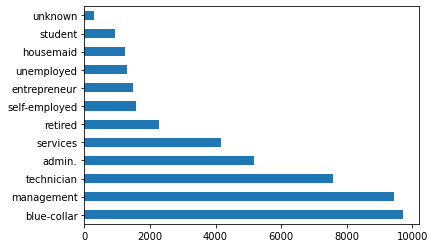

In [ ]:
# 5. Identify jobwise number of customers
bank['job'].value_counts().plot.barh()

In [ ]:
url = 'https://raw.githubusercontent.com/skathirmani/datasets/main/naukri_jobs_datascience.csv'
jobs = pd.read_csv(url)
jobs.shape

(4000, 11)

In [ ]:
jobs.head()

,id,title,location,experience,skills,company,salary,description,posted_date,type,url
0,280918001664,Data Science,Mumbai,2-4 yrs,"Algorithms, Machine Learning, Python, Java, Da...",Netcore Solutions Pvt Ltd,"2,00,000 - 7,00,000 P.A.",At least 2 year of experience in data engineer...,1 day ago,hotjob,https://www.naukri.com/job-listings-Data-Scien...
1,280818003404,Analyst / Sr. Analyst (data Science),Gurgaon,5-8 yrs,"predictive modeling, predictive analytics, mac...",Cvent India Pvt. Ltd.,"5,00,000 - 10,00,000 P.A.",Strong experience on providing predictive mode...,Today,hotjob,https://www.naukri.com/job-listings-Analyst-Sr...
2,280918008755,ETL Lead & Data Science,"Chennai, Bengaluru, Mumbai, Pune, Noida",7-10 yrs,"SQL, Data Analysis, Text Mining, SAS, R, Stati...",COMPUTER POWER GROUP PRIVATE LIMITED,"10,00,000 - 15,00,000 P.A.",Industry experience in building and operationa...,1 day ago,hotjob,https://www.naukri.com/job-listings-ETL-Lead-D...
3,270918901342,Specialist - Data Science,"Delhi NCR, Bengaluru, Gurgaon",7-12 yrs,"Specialist - Data Science, Data Science, data ...",Brainsearch Consulting Pvt Ltd.Â,Not disclosed,- Experience with one or more data science pro...,1 day ago,premium,https://www.naukri.com/job-listings-Specialist...
4,260918002450,Group Manager - Data Science - Python/nlp,Bengaluru,6-11 yrs,"machine learning, text mining, r, nlp, data sc...",Staffio HR,Not disclosed,- This is a Team management role - Skill set ...,1 day ago,premium,https://www.naukri.com/job-listings-Group-Mana...


## Optional Exercises
Using jobs dataset do the following
- Identify location-wise number of opening
- Extract min experience required for each and save it in a new column (use apply method)

## Utility functions
### Type casting

In [ ]:
x = 10
print(float(x)) # int to float

10.0


In [ ]:
y = 10.5
print(int(y)) # float to int

10


In [ ]:
x = '10'
print(int(x)) # str to int

10


In [ ]:
x = '10 years'
print(int(x)) # str to int

ValueError: ignored

In [ ]:
y = '10.5'
print(float(y))

10.5


In [ ]:
x = 'one'
print(int(x))

ValueError: ignored

In [ ]:
input('Enter your age')

Enter your age60


'60'

In [ ]:
user_age = int(input('Enter your age'))
if user_age >= 60:
  print('Your age is %d and you are senior citizen' % user_age)
elif (user_age > 50) and (user_age < 60):
  print('Your age is %d and you are in your middle age') % (user_age)
elif (user_age > 20) and (user_age <= 50):
  print('Your age is %d and you are an Adult' % user_age)
else:
  print('Your age is %d and you are an teenager' % user_age)

Enter your age50
Your age is 50 and you are an Adult


In [ ]:
x = pd.Series(['1', '2', '50', '50'])
x = x.astype(int)
x

0     1
1     2
2    50
3    50
dtype: int64

In [ ]:
x = [True, False, True, False, False]
y = [int(i) for i in x]
y

[1, 0, 1, 0, 0]

In [ ]:
x = [10, 20, 0, -10, 40, 0]
y = [bool(i) for i in x] # Convert each integer to boolean
y

[True, True, False, True, True, False]

In [ ]:
x = [1, 2, 'NA', 4, 5, 40, 'NA']
x.remove('NA')
x

[1, 2, 4, 5, 40, 'NA']

In [ ]:
x = [1, 2, 'NA', 4, 5, 40, 'NA']
del x[2]
del x[-1]
x

[1, 2, 4, 5, 40]

In [ ]:
x = [1, 2, 'NA', 4, 5, 40, 'NA', 40.5]
y = [i for i in x if (type(i) == int) | (type(i) == float)]
y

[1, 2, 4, 5, 40, 40.5]

In [ ]:
x = {'a': 1, 'b': 4, 'c': 5}
del x['b']
x

{'a': 1, 'c': 5}

In [ ]:
x = {'a': 1, 'b': 4, 'c': 5}
x.pop('b')
x

{'a': 1, 'c': 5}

In [ ]:
x = {'a': 1, 'b': 4, 'c': 5}
x.popitem()
x

{'a': 1, 'b': 4}

### While loop

In [ ]:
counter = 0
while counter < 10:
  print(counter)
  counter += 1

0
1
2
3
4
5
6
7
8
9


In [ ]:
password = input('Enter the correct password')
counter = 0
while password != 'abc':
  if counter < 3:
    password = input('Enter the correct password') 
    counter += 1
  else:
    print('Exceed maximum try')
    break

Enter the correct passwordadfad
Enter the correct passwordadf
Enter the correct passwordadfd
Enter the correct passwordadfd
Exceed maximum try


In [ ]:
for i in range(10):
  if i == 4:
    break
  else:
    print(i)

0
1
2
3


In [ ]:
for i in range(10):
  if i == 4:
    continue
  print(i)

0
1
2
3
5
6
7
8
9


In [ ]:
# filter, map, different operators in python

In [ ]:
x = 10
y = 3
print(x / y)
print(x // y) # quotient
print(x % y) # reminder

3.3333333333333335
3
1
